<a href="https://colab.research.google.com/github/HTKhuongNinh-FPTU/ML-Models/blob/main/Ridge_Reg_LaptopPrice_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ĐỒ ÁN MÔN HỌC: MATHEMATICS FOR MACHINE LEARNING (MAI391)**
**# Đề tài: Phân tích và dự báo giá máy tính bằng phương pháp Hồi quy Ridge và Phân tích nhân tố trên bộ dữ liệu Laptop Price**

# 1. Giới thiệu lý thuyết ước lượng OLS

Trong Machine Learning, bài toán hồi quy tuyến tính giả định mối quan hệ giữa các đặc trưng (như RAM, CPU, Weight...) và giá máy là tuyến tính. Mô hình có dạng:

$$\hat{y} = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n$$

Trong đó:
* $\hat{y}$: Giá trị dự báo (Price).
* $x_i$: Các đặc trưng đầu vào (Ram, Weight...).
* $\beta_i$: Các hệ số hồi quy cần tìm.

### Mục tiêu của phương pháp OLS (Ordinary Least Squares)
Để tìm bộ tham số $\beta$ tối ưu, ta sử dụng phương pháp **OLS**. Mục tiêu là cực tiểu hóa hàm mất mát (Loss function), cụ thể là sai số bình phương trung bình **(MSE - Mean Squared Error)**:

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Việc cực tiểu hóa hàm này giúp đường hồi quy nằm gần các điểm dữ liệu thực tế nhất có thể.

---
# 2. Xử lý – Giảm thiểu Overfitting

Để đảm bảo mô hình không chỉ "học vẹt" trên dữ liệu huấn luyện mà còn dự báo tốt trên dữ liệu mới, chúng ta áp dụng:
1.  **Chia dữ liệu (Train-Test Split):** Tỉ lệ 8/2 giúp đánh giá khách quan năng lực của mô hình.
2.  **Hồi quy Ridge (L2 Regularization):** Thêm thành phần điều tiết vào hàm Loss để kiểm soát độ lớn của các hệ số $\beta$, tránh mô hình quá phức tạp gây ra Overfitting.

**Cell 1: Import thư viện & Load Data**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Đọc dữ liệu
df = pd.read_csv('laptop_price.csv', encoding='latin-1')
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


**Cell 2: Tiền xử lý (Feature Engineering)**

Làm sạch dữ liệu: Loại bỏ đơn vị "GB" ở cột Ram và "kg" ở cột Weight, chuyển chúng về kiểu dữ liệu số (int, float).

Mã hóa đặc trưng (Encoding): Sử dụng LabelEncoder để biến đổi các đặc trưng văn bản thành các giá trị số nguyên.



In [ ]:
# 1. Hàm làm sạch dữ liệu an toàn
def clean_unit(value, unit):
    if isinstance(value, str): # Chỉ xử lý nếu nó đang là chuỗi
        return value.replace(unit, '')
    return value # Nếu là số rồi thì trả về luôn

# Áp dụng cho Ram và Weight
df['Ram'] = df['Ram'].apply(lambda x: clean_unit(x, 'GB')).astype(int)
df['Weight'] = df['Weight'].apply(lambda x: clean_unit(x, 'kg')).astype(float)

# 2. Mã hóa các cột dạng chữ sang số (Label Encoding)
le = LabelEncoder()
categorical_cols = ['Product', 'ScreenResolution', 'Cpu', 'Memory', 'Gpu']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Tiền xử lý hoàn tất !")

Tiền xử lý hoàn tất !


**Cell 3: Chọn biến & Chia tập dữ liệu**

- Danh sách Feature sử dụng: Product, Inches, ScreenResolution, Cpu, Ram, Memory, Gpu, Weight. Đây là các yếu tố ảnh hưởng trực tiếp đến giá thành sản phẩm.
- Chia tập dữ liệu tỉ lệ : 8/2

In [ ]:
# Lựa chọn 8 Features
features = ['Product', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'Weight']
X = df[features]
y = df['Price_euros']

# Chia tập 8:2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Cố định khi khởi tạo mô hình
model = Ridge(alpha=1.0, random_state=42)
print(f"Sẵn sàng huấn luyện với {len(features)} đặc trưng.")

# 1. Kiểm tra số lượng mẫu (Số dòng)
n_train = X_train.shape[0]
n_test = X_test.shape[0]
total = n_train + n_test

# 2. Tính tỷ lệ phần trăm
p_train = (n_train / total) * 100
p_test = (n_test / total) * 100

# 3. In ra kết quả chuyên nghiệp
print("--- THỐNG KÊ PHÂN CHIA DỮ LIỆU ---")
print(f"Tổng cộng mẫu: {total} laptop")
print(f"Số lượng Train: {n_train} mẫu ({p_train:.0f}%) -> Dùng để mô hình 'học' quy luật.")
print(f"Số lượng Test : {n_test} mẫu ({p_test:.0f}%) -> Dùng để 'thi' và đánh giá độ chính xác.")

Sẵn sàng huấn luyện với 8 đặc trưng.
--- THỐNG KÊ PHÂN CHIA DỮ LIỆU ---
Tổng cộng mẫu: 1303 laptop
Số lượng Train: 1042 mẫu (80%) -> Dùng để mô hình 'học' quy luật.
Số lượng Test : 261 mẫu (20%) -> Dùng để 'thi' và đánh giá độ chính xác.


**Cell 4: Huấn luyện mô hình** **Ridge**

In [ ]:
# alpha=1.0 là tham số L2 giúp chống Overfitting
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

print("Mô hình đã huấn luyện xong!")

Mô hình đã huấn luyện xong!


**Cell 5: Đánh giá & Trực quan hóa**

**5.1 Bảng hệ số hồi quy**

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Cố định cấu hình hiển thị
pd.set_option('display.max_colwidth', None)

# 2. Tính toán P-value bằng statsmodels (Cần thiết cho cột Tin cậy)
X_with_constant = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_with_constant).fit()
p_values = ols_model.pvalues

# 3. Trích xuất thông số từ model Ridge của Ninh
intercept = model.intercept_
coefficients = model.coef_
feature_names = ['Product', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'Weight']

# 4. Tạo DataFrame full_report (Định nghĩa biến ở đây)
data = {
    'Đặc trưng': ['Intercept (Hằng số chặn)'] + feature_names,
    'Hệ số (Weight)': [intercept] + list(coefficients),
    'P-value': [p_values['const']] + [p_values[feat] for feat in feature_names]
}
full_report = pd.DataFrame(data)

# 5. Hàm giải thích thông minh
def smart_explain(row):
    feat = row['Đặc trưng']
    coef = row['Hệ số (Weight)']
    p = float(row['P-value'])
    status = "Tin cậy" if p < 0.05 else "Ít tin cậy"

    if "Intercept" in feat:
        return f"Giá khởi điểm của máy. ({status})"

    direction = "Tăng" if coef > 0 else "Giảm"
    return f"{direction} {abs(coef):.2f}€ mỗi đơn vị {feat}. ({status})"

# 6. Áp dụng giải thích và định dạng
full_report['Giải thích & Tin cậy'] = full_report.apply(smart_explain, axis=1)
full_report['Hệ số (Weight)'] = full_report['Hệ số (Weight)'].round(2)
full_report['P-value (Định dạng)'] = full_report['P-value'].apply(
    lambda x: f"{x:.4f}" if x >= 0.0001 else "0.0000")

# 7. In kết quả cuối cùng
print(f"{'--- BẢNG GIẢI MÃ HỆ SỐ & ĐỘ TIN CẬY ---':^70}")
print(full_report[['Đặc trưng', 'Hệ số (Weight)', 'P-value (Định dạng)',
                   'Giải thích & Tin cậy']].to_string(index=False))

               --- BẢNG GIẢI MÃ HỆ SỐ & ĐỘ TIN CẬY ---                
               Đặc trưng  Hệ số (Weight) P-value (Định dạng)                               Giải thích & Tin cậy
Intercept (Hằng số chặn)          311.74              0.1278                Giá khởi điểm của máy. (Ít tin cậy)
                 Product            0.20              0.0112           Tăng 0.20€ mỗi đơn vị Product. (Tin cậy)
                  Inches          -53.53              0.0011           Giảm 53.53€ mỗi đơn vị Inches. (Tin cậy)
        ScreenResolution           10.36              0.0000 Tăng 10.36€ mỗi đơn vị ScreenResolution. (Tin cậy)
                     Cpu            4.59              0.0000               Tăng 4.59€ mỗi đơn vị Cpu. (Tin cậy)
                     Ram           78.33              0.0000              Tăng 78.33€ mỗi đơn vị Ram. (Tin cậy)
                  Memory            6.98              0.0000            Tăng 6.98€ mỗi đơn vị Memory. (Tin cậy)
                     Gpu         

**5.2 Đánh giá mô hình (Evaluation)**

Chỉ số sử dụng:

- R2 Score: Đo lường tỷ lệ sự biến động của giá được giải thích bởi mô hình .

- MAE (Mean Absolute Error): Sai số tuyệt đối trung bình, cho biết mức chênh lệch thực tế tính bằng Euro.

- RMSE (Root Mean Squared Error): Căn bậc hai của MSE, giúp phạt nặng các sai số lớn, phản ánh độ ổn định của dự báo.

Trực quan hóa: Sử dụng biểu đồ Actual vs Predicted để quan sát sự hội tụ của dữ liệu quanh đường 45 độ. Chấm xanh càng gần đường đỏ thì dự báo càng chính xác.

   --- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH RIDGE ---    
Chỉ số          | Giá trị         | Ý nghĩa             
-------------------------------------------------------
R2 Score        | 0.6009          | Độ khớp (0-1)
Adjusted R2     | 0.5883          | Độ khớp điều chỉnh
MAE             | 310.81     Euro | Sai số trung bình
RMSE            | 450.22     Euro | Sai số phạt nặng
MAPE            | 34.05      %    | Sai số phần trăm TB
-------------------------------------------------------


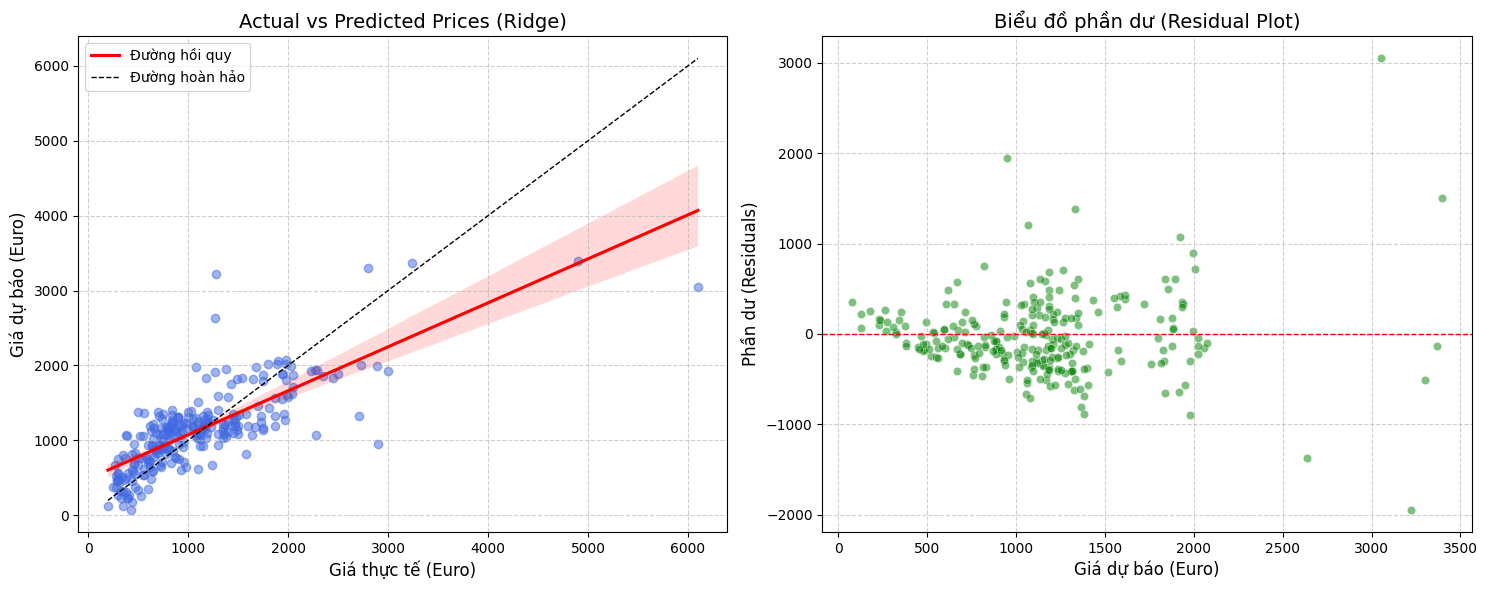

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 1. Dự báo
y_pred = model.predict(X_test)

# 2. Tính toán các chỉ số quan trọng
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Adjusted R-squared
n = len(y_test) # number of observations
p = len(X.columns) # number of features
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# MAPE (Mean Absolute Percentage Error)
# Avoid division by zero, though for laptop prices it's unlikely y_test will be 0
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# 3. In kết quả định dạng chuyên nghiệp
print(f"{'--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH RIDGE ---':^45}")
print(f"{'Chỉ số':<15} | {'Giá trị':<15} | {'Ý nghĩa':<20}")
print("-" * 55)
print(f"{'R2 Score':<15} | {r2:<15.4f} | {'Độ khớp (0-1)'}")
print(f"{'Adjusted R2':<15} | {adjusted_r2:<15.4f} | {'Độ khớp điều chỉnh'}")
print(f"{'MAE':<15} | {mae:<10.2f} Euro | {'Sai số trung bình'}")
print(f"{'RMSE':<15} | {rmse:<10.2f} Euro | {'Sai số phạt nặng'}")
print(f"{'MAPE':<15} | {mape:<10.2f} %    | {'Sai số phần trăm TB'}")
print("-" * 55)

# 4. Vẽ biểu đồ trực quan
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # First subplot for Actual vs Predicted
sns.regplot(x=y_test, y=y_pred,
            scatter_kws={'alpha':0.5, 'color':'royalblue'},
            line_kws={'color':'red', 'label':'Đường hồi quy'})
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1, label='Đường hoàn hảo')
plt.xlabel('Giá thực tế (Euro)', fontsize=12)
plt.ylabel('Giá dự báo (Euro)', fontsize=12)
plt.title('Actual vs Predicted Prices (Ridge)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2) # Second subplot for Residual Plot
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color='green')
plt.axhline(y=0, color='red', linestyle='--', lw=1)
plt.xlabel('Giá dự báo (Euro)', fontsize=12)
plt.ylabel('Phần dư (Residuals)', fontsize=12)
plt.title('Biểu đồ phần dư (Residual Plot)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Kết luận và Nhận xét (Conclusion)
- Hiệu suất dự báo thực tế: Mô hình đạt độ chính xác ổn định ($R^2 \approx 0.6$). Trong bối cảnh dữ liệu thị trường có nhiều biến động, việc giải thích được 60% sự biến thiên của giá chỉ qua các thông số kỹ thuật cốt lõi là một minh chứng cho thấy mô hình đã nắm bắt được quy luật kinh tế cơ bản của sản phẩm.
- Hạn chế: Chỉ số $R^2$ chưa đạt mức tuyệt đối (0.9) do dữ liệu còn thiếu các yếu tố "mềm" như vật liệu vỏ máy, phí thương hiệu (Apple, Razer) và sự biến động giá ảo trên thị trường.
- Hướng phát triển: Có thể áp dụng PCA để giảm chiều dữ liệu hoặc sử dụng các kỹ thuật mã hóa nâng cao hơn như One-Hot Encoding cho các biến có ít giá trị phân biệt.

**Những vấn đề được giải quyết**
- Về phân tích nhân tố: "Thông qua bảng hệ số hồi quy và chỉ số P-value, em xác định được Trọng lượng (Weight) và RAM là hai nhân tố chính thúc đẩy giá thành, trong khi Kích thước màn hình (Inches) lại có xu hướng tỉ lệ nghịch với giá ở phân khúc phổ thông."
- Về giá trị: "Mô hình này có thể giúp người dùng định giá nhanh một chiếc laptop dựa trên cấu hình, hoặc giúp các cửa hàng tối ưu hóa giá bán."
- Ví dụ thực tế (Chiến lược mua máy rẻ): "muốn mua máy laptop càng rẻ thì hay chọn máy có kích thước màn hình lớn , dung lượng RAM thấp nhất có thể và trọng lượng vừa phải (vỏ nhựa)".